In [5]:
#Baseline Algorithms, Function Implementations
from Single_ag_Environment import SingleSatelliteEnv
from gymnasium.utils.env_checker import check_env
import traceback
import numpy as np
print(type(SingleSatelliteEnv))
# This will catch many common issues
env = SingleSatelliteEnv()
try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print("Environment has issues:")
    traceback.print_exc()

<class 'type'>
Environment passes all checks!


In [34]:
#Here we implement Baseline CGR as a function that can be called 
def BaselineCGR(env,seed):
    
    init_observation,init_info=env.reset(seed)
    #print(init_observation)
    delivery_ratio_metric=None
    contact_energy_efficiency=None
    total_reward=0
    done=False
    while not done:
        action = 1
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
    #Next we need to extract final info from the episode
    initial_data_volume=info["Initial Data"]
    delivered_packets=info["Delivered Data"]
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    env.close()

    

In [84]:

def AdaptiveSorting(env,seed):
    initial_observation,initial_information=env.reset(seed)
    initial_data_volume=initial_observation["Remaining data"]*100
    contacts_available=initial_observation["contact plan"]
    sorted_matrix=np.zeros([10,2])
    current_contact_iterator=0
    #Next we must calculate the initial allocation of contacts
    j=0
    for i in contacts_available:
        sorted_matrix[j,0]=i
        sorted_matrix[j,1]=j
        j=j+1
    sorted_matrix=sorted_matrix[sorted_matrix[:, 0].argsort()]
    print("Initial Sorted Matrix")
    print(sorted_matrix)
    remaining_data=initial_data_volume
    print("Initial Data to send")
    print(remaining_data)
    decision_matrix=np.zeros([10,2])
    
    j=0
    for i in range(0,len(decision_matrix)):
        if (remaining_data>0):
            if sorted_matrix[i,0]<1:
                remaining_data=remaining_data-(10-sorted_matrix[i,0]*10)
                
                decision_matrix[i,0]=1
                decision_matrix[i,1]=sorted_matrix[i,1]
            else:
                decision_matrix[i,0]=0
                decision_matrix[i,1]=sorted_matrix[i,1]
        else:
            decision_matrix[i,0]=0
            decision_matrix[i,1]=sorted_matrix[i,1]
    #Next we must reorder the decision matrix
    
    done=False
    print("Decision Matrix")
    print(decision_matrix)
    sorted_decisions=decision_matrix[decision_matrix[:,1].argsort()]
    print("Sorted Decisions")
    print(sorted_decisions)
    action_decision_matrix=np.zeros(10)
    for i in range(0,len(sorted_decisions)):
        action_decision_matrix[i]=sorted_decisions[i,0]
    print("Actual set of Actions")
    print(action_decision_matrix)
    obs=initial_observation
    i=0
    while not done:
        #print(i)
        print("Next Decision")
        print(action_decision_matrix[i])
        if action_decision_matrix[i]==0:
            #We don't use this contact
            action=0
            next_obs, reward, terminated, truncated, info = env.step(action)
        else:
            #We use the contact
            
            action=1
            next_obs, reward, terminated, truncated, info = env.step(action)
            #Next we need to determine if we successfully delivered any packets
            current_delivered=next_obs["Remaining data"]
            previous_delivered=obs["Remaining data"]
            if (current_delivered>previous_delivered):
                #We need to recalculate the decision matrix
                remaining_data=current_delivered*100
                aux_sorting_matrix=np.zeros([10,2])
                for j in range(0,9):
                    aux_sorting_matrix[j,0]=contacts_available[j]
                    aux_sorting_matrix[j,1]=j
                for j in range(0,i):
                    aux_sorting_matrix[j,0]=1
                    
                aux_sorting_matrix=aux_sorted_matrix[aux_sorted_matrix[:, 0].argsort()]
                decision_matrix=np.zeros([10,2])
                k=0
                for j in range(0,len(decision_matrix)):
                    if remaining_data>0:
                        if aux_sorted_matrix[j,0]<1:
                            remaining_data=remaining_data-(10-aux_sorted_matrix[j,0]*10)
                            decision_matrix[j,0]=1
                            decision_matrix[j,1]=aux_sorted_matrix[j,1]
                        else:
                            decision_matrix[j,0]=0
                            decision_matrix[j,1]=aux_sorted_matrix[j,1]
                    else:
                        decision_matrix[j,0]=0
                        decision_matrix[j,1]=aux_sorted_matrix[j,1]

                aux_sorted_decisions=decision_matrix[decision_matrix[:,1].argsort()]
                action_decision_matrix=np.zeros(10)
                for k in range(0,len(sorted_decisions)-1):
                    action_decision_matrix[k]=aux_sorted_decisions[k,0]
        obs=next_obs
        i=i+1
        if terminated==False and truncated==False:
            done=False
        else:
            done=True
    #Next we need to graph and log the results of the heuristic algorithm
    initial_data_volume=info["Initial Data"]
    delivered_packets=info["Delivered Data"]
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    print("Delivered Packets")
    print(delivered_packets)
    print("Number of Contacts")
    print(number_of_contacts)
    print("Initial Data Volume")
    print(initial_data_volume)
    return total_reward,intial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    env.close()


In [85]:
#Basic debugging tests for sorting algorithm
total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=AdaptiveSorting(env,50)



Initial Sorted Matrix
[[0.1        6.        ]
 [0.2        4.        ]
 [0.30000001 9.        ]
 [0.40000001 8.        ]
 [0.5        2.        ]
 [0.60000002 5.        ]
 [0.60000002 7.        ]
 [0.80000001 0.        ]
 [0.80000001 1.        ]
 [1.         3.        ]]
Initial Data to send
[70.]
Decision Matrix
[[1. 6.]
 [1. 4.]
 [1. 9.]
 [1. 8.]
 [1. 2.]
 [1. 5.]
 [1. 7.]
 [1. 0.]
 [1. 1.]
 [0. 3.]]
Sorted Decisions
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [0. 3.]
 [1. 4.]
 [1. 5.]
 [1. 6.]
 [1. 7.]
 [1. 8.]
 [1. 9.]]
Actual set of Actions
[1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]
Next Decision
1.0
Next Decision
1.0
Next Decision
1.0
Next Decision
0.0
Next Decision
1.0
Next Decision
1.0
Next Decision
1.0
Next Decision
1.0
Next Decision
1.0
Next Decision
1.0
Delivered Packets
37
Number of Contacts
9
Initial Data Volume
[0.7]


/tmp/ipykernel_3439429/795334572.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  CGR_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
/tmp/ipykernel_3439429/795334572.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Sorting_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)


Initial Sorted Matrix
[[0.1        6.        ]
 [0.2        4.        ]
 [0.30000001 9.        ]
 [0.40000001 8.        ]
 [0.5        2.        ]
 [0.60000002 5.        ]
 [0.60000002 7.        ]
 [0.80000001 0.        ]
 [0.80000001 1.        ]
 [1.         3.        ]]
Initial Data to send
[70.]
Decision Matrix
[[1. 6.]
 [1. 4.]
 [1. 9.]
 [1. 8.]
 [1. 2.]
 [1. 5.]
 [1. 7.]
 [1. 0.]
 [1. 1.]
 [0. 3.]]
Sorted Decisions
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [0. 3.]
 [1. 4.]
 [1. 5.]
 [1. 6.]
 [1. 7.]
 [1. 8.]
 [1. 9.]]
Actual set of Actions
[1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]
Next Decision
1.0
Next Decision
1.0
Next Decision
1.0
Next Decision
0.0
Next Decision
1.0
Next Decision
1.0
Next Decision
1.0
Next Decision
1.0
Next Decision
1.0
Next Decision
1.0
Delivered Packets
37
Number of Contacts
9
Initial Data Volume
[0.7]
Delivered Packets
37
Number of Contacts
9
Initial Sorted Matrix
[[0.2        3.        ]
 [0.2        5.        ]
 [0.30000001 2.        ]
 [0.30000001 1.        ]
 [0.40000001 8.    

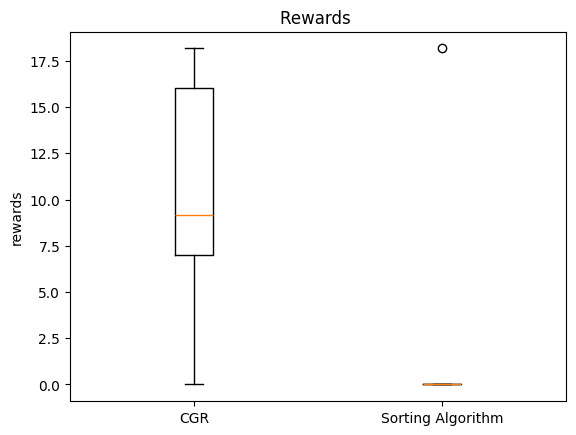

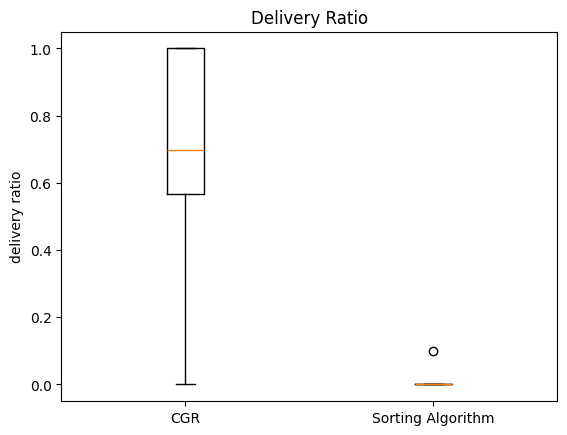

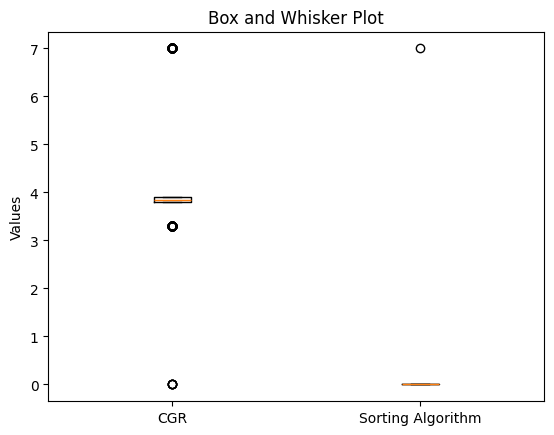

In [86]:
#Next we need to test these baseline algorithms and produce delivery, reward and contact energy efficiency
#graphs
Number_of_Episodes=100
seeds=[50,51,52,53,54]
CGR_reward_vector=np.zeros(len(seeds)*Number_of_Episodes)
CGR_delivery_ratio_vector=np.zeros(len(seeds)*Number_of_Episodes)
CGR_mean_contact_energy_efficiency_vector=np.zeros(len(seeds)*Number_of_Episodes)
vector_index=0
for h in range(1,Number_of_Episodes):
        for b in seeds:
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=BaselineCGR(env,b)
            vector_index+=1
            CGR_reward_vector[vector_index]=total_reward
            CGR_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
            CGR_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/number_of_contacts

#Next we must make box plots these results



#Adaptive sorting Algorithm

Sorting_reward_vector=np.zeros(len(seeds)*Number_of_Episodes)
Sorting_delivery_ratio_vector=np.zeros(len(seeds)*Number_of_Episodes)
Sorting_mean_contact_energy_efficiency_vector=np.zeros(len(seeds)*Number_of_Episodes)
vector_index=0
for h in range(1,Number_of_Episodes):
        for b in seeds:
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=AdaptiveSorting(env,b)
            Sorting_reward_vector[vector_index]=total_reward
            Sorting_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
            print("Delivered Packets")
            print(delivered_packets)
            print("Number of Contacts")
            print(number_of_contacts)
            Sorting_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/number_of_contacts

import matplotlib.pyplot as plt
#Reward Plot
print(np.mean(Sorting_reward_vector))
plt.boxplot([CGR_reward_vector, Sorting_reward_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Rewards ")
plt.ylabel("rewards")
plt.show()

#Delivery Ratio Plot
plt.boxplot([CGR_delivery_ratio_vector, Sorting_delivery_ratio_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Delivery Ratio")
plt.ylabel("delivery ratio")
plt.show()
#Contact Energy Efficiency Plot
plt.boxplot([CGR_mean_contact_energy_efficiency_vector, Sorting_mean_contact_energy_efficiency_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Box and Whisker Plot")
plt.ylabel("Values")
plt.show()